# Black-Scholes Option Pricing Lab

This notebook implements the Black-Scholes model for European option pricing, including call and put valuation, Greeks calculation, sensitivity analysis and payoff visualisation.

The project was first built in Excel to understand the mechanics step by step, and is then replicated in Python to make the model reusable and scalable.

## 1. Project Overview

The objective of this project is to price European call and put options using the Black-Scholes framework.

The model uses the following inputs:

- Spot price
- Strike price
- Time to maturity
- Risk-free rate
- Volatility
- Dividend yield

The notebook also calculates the main Greeks and performs sensitivity analysis to understand how option prices and risk measures react to changes in market variables.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

## 2. Model Inputs

We define the base inputs used in the Black-Scholes model.

In [2]:
S0 = 100      # Current underlying price
K = 100       # Strike price
T = 1         # Time to maturity in years
r = 0.05      # Risk-free rate
sigma = 0.20  # Volatility
q = 0.00      # Dividend yield

In [3]:
inputs = pd.DataFrame({"Input": ["Spot Price", "Strike Price", "Time to Maturity", "Risk-Free Rate", "Volatility", "Dividend Yield"],"Value": [S0, K, T, r, sigma, q]})
inputs

,Input,Value
0,Spot Price,100.00
1,Strike Price,100.00
2,Time to Maturity,1.00
3,Risk-Free Rate,0.05
4,Volatility,0.20
5,Dividend Yield,0.00


## 3. Intermediate Calculations: d1 and d2

The variables d1 and d2 are intermediate calculations used in the Black-Scholes formula.

In [5]:
d1 = (np.log(S0 / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

print(d1, d2)

0.35000000000000003 0.15000000000000002


In [8]:
Nd1 = norm.cdf(d1)
Nd2 = norm.cdf(d2)
NnegativeD1 = norm.cdf(-d1)
NnegativeD2 = norm.cdf(-d2)

print(Nd1, Nd2, NnegativeD1, NnegativeD2)

0.6368306511756191 0.5596176923702425 0.3631693488243809 0.4403823076297575


In [9]:
intermediateCalculations = pd.DataFrame({"Calculation": ["d1", "d2", "N(d1)", "N(d2)", "N(-d1)", "N(-d2)"],"Value": [d1, d2, Nd1, Nd2, NnegativeD1, NnegativeD2]})
intermediateCalculations

,Calculation,Value
0,d1,0.350000
1,d2,0.150000
2,N(d1),0.636831
3,N(d2),0.559618
4,N(-d1),0.363169
5,N(-d2),0.440382


## 4. Black-Scholes Option Prices

We now calculate the theoretical prices of a European call and put option using the Black-Scholes formula.

In [11]:
callPrice = S0 * np.exp(-q * T) * Nd1 - K * np.exp(-r * T) * Nd2
putPrice = K * np.exp(-r * T) * NnegativeD2 - S0 * np.exp(-q * T) * NnegativeD1

print(callPrice, putPrice)

10.450583572185565 5.573526022256971


In [12]:
optionPrices = pd.DataFrame({"Option": ["Call", "Put"],"Theoretical Price": [callPrice, putPrice]})
optionPrices

,Option,Theoretical Price
0,Call,10.450584
1,Put,5.573526


## 5. Put-Call Parity Check

Put-call parity is a no-arbitrage relationship linking the prices of European calls and puts with the same strike and maturity.

In [17]:
putCallParity = pd.DataFrame({"Component": ["Parity LHS: Call - Put", "Parity RHS: S0e^(-qT) - Ke^(-rT)", "Difference"],"Value": [parityLHS, parityRHS, parityDifference]})
putCallParity.style.format({"Value": "{:.4f}"})

,Component,Value
0,Parity LHS: Call - Put,4.8771
1,Parity RHS: S0e^(-qT) - Ke^(-rT),4.8771
2,Difference,0.0000


## 6. Black-Scholes Pricing Function

We now wrap the Black-Scholes formula into a reusable Python function.

In [23]:
def blackScholesPrice(S0, K, T, r, sigma, q=0.0):
    d1 = (np.log(S0 / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    callPrice = S0 * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    putPrice = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * np.exp(-q * T) * norm.cdf(-d1)

    return callPrice, putPrice

In [20]:
callPriceFunction, putPriceFunction = blackScholesPrice(S0, K, T, r, sigma, q)
print(f"Call Price: {callPriceFunction:.4f}")
print(f"Put Price: {putPriceFunction:.4f}")

Call Price: 10.4506
Put Price: 5.5735


## 7. Black-Scholes Greeks Function

The Greeks measure how sensitive the option price is to changes in the main market variables.

In [25]:
def blackScholesGreeks(S0, K, T, r, sigma, q=0.0):
    d1 = (np.log(S0 / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    phiD1 = norm.pdf(d1)

    deltaCall = np.exp(-q * T) * norm.cdf(d1)
    deltaPut = np.exp(-q * T) * (norm.cdf(d1) - 1)
    gamma = np.exp(-q * T) * phiD1 / (S0 * sigma * np.sqrt(T))
    vega = S0 * np.exp(-q * T) * phiD1 * np.sqrt(T) / 100
    thetaCall = (-(S0 * np.exp(-q * T) * phiD1 * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2) + q * S0 * np.exp(-q * T) * norm.cdf(d1)) / 365
    thetaPut = (-(S0 * np.exp(-q * T) * phiD1 * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2) - q * S0 * np.exp(-q * T) * norm.cdf(-d1)) / 365
    rhoCall = K * T * np.exp(-r * T) * norm.cdf(d2) / 100
    rhoPut = -K * T * np.exp(-r * T) * norm.cdf(-d2) / 100

    return {"Delta Call": deltaCall,"Delta Put": deltaPut,"Gamma": gamma,"Vega": vega,"Theta Call": thetaCall,"Theta Put": thetaPut,"Rho Call": rhoCall,"Rho Put": rhoPut}

In [27]:
greeks = blackScholesGreeks(S0, K, T, r, sigma, q)
greeksTable = pd.DataFrame({"Greek": greeks.keys(),"Value": greeks.values()})
greeksTable

,Greek,Value
0,Delta Call,0.636831
1,Delta Put,-0.363169
2,Gamma,0.018762
3,Vega,0.375240
4,Theta Call,-0.017573
5,Theta Put,-0.004542
6,Rho Call,0.532325
7,Rho Put,-0.418905


## 8. Sensitivity Analysis: Option Price vs Spot Price

We analyse how the theoretical call and put prices change when the underlying spot price changes, while keeping all other inputs constant.

In [29]:
spotRange = np.arange(60, 145, 5)

spotSensitivityTable = pd.DataFrame([[spot, *blackScholesPrice(spot, K, T, r, sigma, q)] for spot in spotRange],columns=["Spot Price", "Call Price", "Put Price"])
spotSensitivityTable

,Spot Price,Call Price,Put Price
0,60,0.054437,35.177379
1,65,0.171419,30.294362
2,70,0.441448,25.564391
3,75,0.967228,21.090170
4,80,1.859420,16.982362
5,85,3.213599,13.336541
6,90,5.091222,10.214165
7,95,7.510872,7.633815
8,100,10.450584,5.573526
9,105,13.857906,3.980849


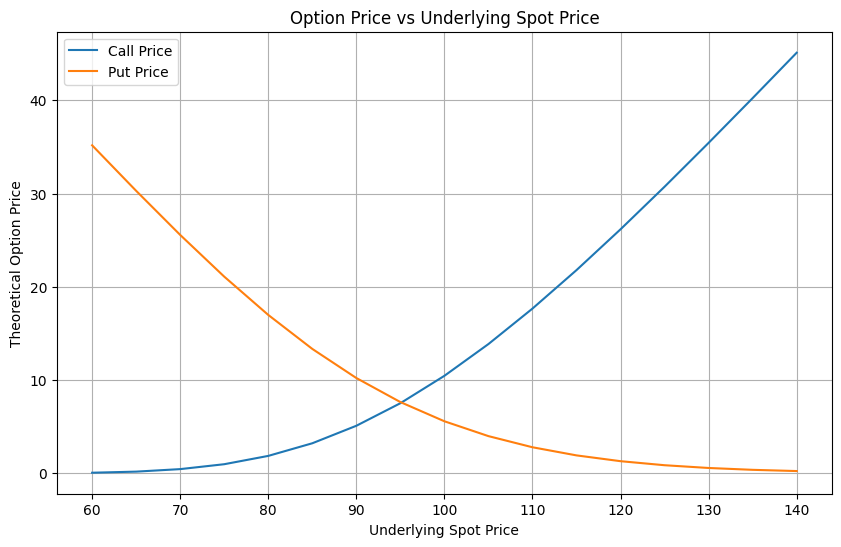

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(spotSensitivityTable["Spot Price"], spotSensitivityTable["Call Price"], label="Call Price")
plt.plot(spotSensitivityTable["Spot Price"], spotSensitivityTable["Put Price"], label="Put Price")

plt.title("Option Price vs Underlying Spot Price")
plt.xlabel("Underlying Spot Price")
plt.ylabel("Theoretical Option Price")
plt.legend()
plt.grid(True)
plt.show()

## 9. Sensitivity Analysis: Option Price vs Volatility

We analyse how the theoretical call and put prices change when volatility changes, while keeping all other inputs constant.

In [32]:
volatilityRange = np.arange(0.05, 0.55, 0.05)
volatilitySensitivityTable = pd.DataFrame([[vol, *blackScholesPrice(S0, K, T, r, vol, q)] for vol in volatilityRange],columns=["Volatility", "Call Price", "Put Price"])

volatilitySensitivityTable

,Volatility,Call Price,Put Price
0,0.05,5.283269,0.406211
1,0.10,6.804958,1.927900
2,0.15,8.591658,3.714601
3,0.20,10.450584,5.573526
4,0.25,12.335999,7.458941
5,0.30,14.231255,9.354197
6,0.35,16.128429,11.251371
7,0.40,18.022951,13.145894
8,0.45,19.911770,15.034712
9,0.50,21.792604,16.915547


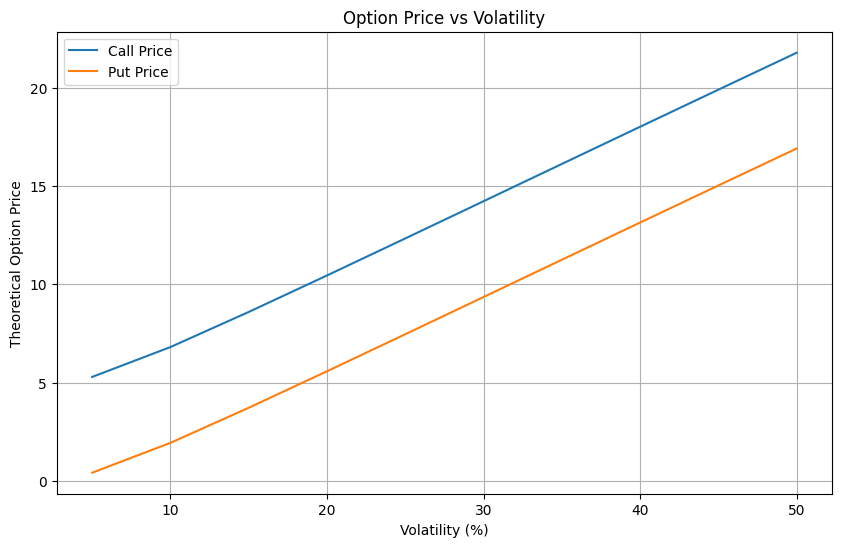

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(volatilitySensitivityTable["Volatility"] * 100, volatilitySensitivityTable["Call Price"], label="Call Price")
plt.plot(volatilitySensitivityTable["Volatility"] * 100, volatilitySensitivityTable["Put Price"], label="Put Price")

plt.title("Option Price vs Volatility")
plt.xlabel("Volatility (%)")
plt.ylabel("Theoretical Option Price")
plt.legend()
plt.grid(True)
plt.show()

## 10. Sensitivity Analysis: Option Price vs Time to Maturity

We analyse how the theoretical call and put prices change when time to maturity changes, while keeping all other inputs constant.

In [36]:
timeRange = np.array([0.10, 0.25, 0.50, 0.75, 1.00, 1.50, 2.00, 3.00])
timeSensitivityTable = pd.DataFrame( [[time, *blackScholesPrice(S0, K, time, r, sigma, q)] for time in timeRange], columns=["Time to Maturity", "Call Price", "Put Price"])

timeSensitivityTable

,Time to Maturity,Call Price,Put Price
0,0.10,2.773654,2.274902
1,0.25,4.614997,3.372777
2,0.50,6.888729,4.419720
3,0.75,8.772268,5.091710
4,1.00,10.450584,5.573526
5,1.50,13.442905,6.217253
6,2.00,16.126780,6.610522
7,3.00,20.924361,6.995159


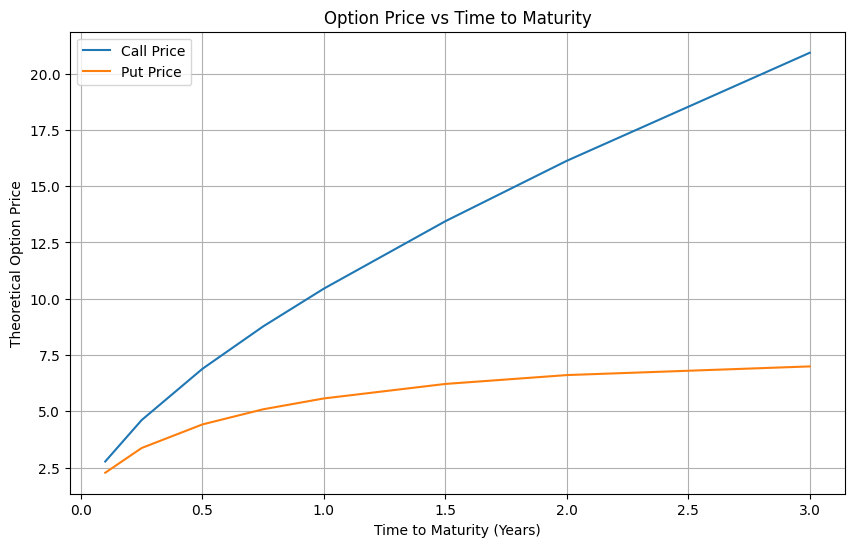

In [37]:
plt.figure(figsize=(10, 6))
plt.plot(timeSensitivityTable["Time to Maturity"], timeSensitivityTable["Call Price"], label="Call Price")
plt.plot(timeSensitivityTable["Time to Maturity"], timeSensitivityTable["Put Price"], label="Put Price")

plt.title("Option Price vs Time to Maturity")
plt.xlabel("Time to Maturity (Years)")
plt.ylabel("Theoretical Option Price")
plt.legend()
plt.grid(True)
plt.show()

## 11. Greeks Sensitivity vs Spot Price

We analyse how the main Greeks change when the underlying spot price changes, while keeping all other inputs constant.

In [38]:
greeksSensitivityTable = pd.DataFrame(
    [[spot, blackScholesGreeks(spot, K, T, r, sigma, q)["Delta Call"],
            blackScholesGreeks(spot, K, T, r, sigma, q)["Delta Put"],
            blackScholesGreeks(spot, K, T, r, sigma, q)["Gamma"],
            blackScholesGreeks(spot, K, T, r, sigma, q)["Vega"]]
     for spot in spotRange],
    columns=["Spot Price", "Delta Call", "Delta Put", "Gamma", "Vega"]
)

greeksSensitivityTable

,Spot Price,Delta Call,Delta Put,Gamma,Vega
0,60,0.013758,-0.986242,0.002929,0.021092
1,65,0.035622,-0.964378,0.006030,0.050957
2,70,0.075875,-0.924125,0.010201,0.099969
3,75,0.138207,-0.861793,0.014709,0.165474
4,80,0.221922,-0.778078,0.018598,0.238057
5,85,0.321827,-0.678173,0.021086,0.304692
6,90,0.429832,-0.570168,0.021820,0.353480
7,95,0.537260,-0.462740,0.020905,0.377341
8,100,0.636831,-0.363169,0.018762,0.375240
9,105,0.723727,-0.276273,0.015925,0.351152


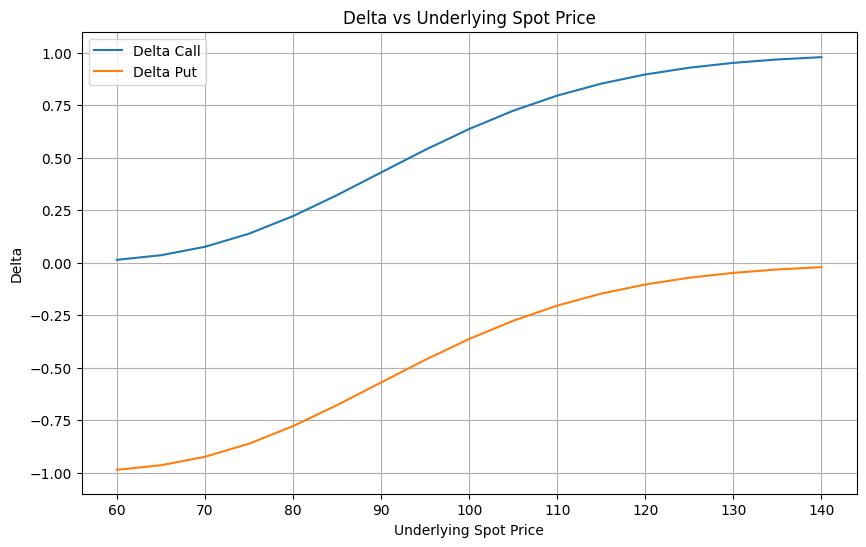

In [39]:
plt.figure(figsize=(10, 6))
plt.plot(greeksSensitivityTable["Spot Price"], greeksSensitivityTable["Delta Call"], label="Delta Call")
plt.plot(greeksSensitivityTable["Spot Price"], greeksSensitivityTable["Delta Put"], label="Delta Put")

plt.title("Delta vs Underlying Spot Price")
plt.xlabel("Underlying Spot Price")
plt.ylabel("Delta")
plt.ylim(-1.1, 1.1)
plt.legend()
plt.grid(True)
plt.show()

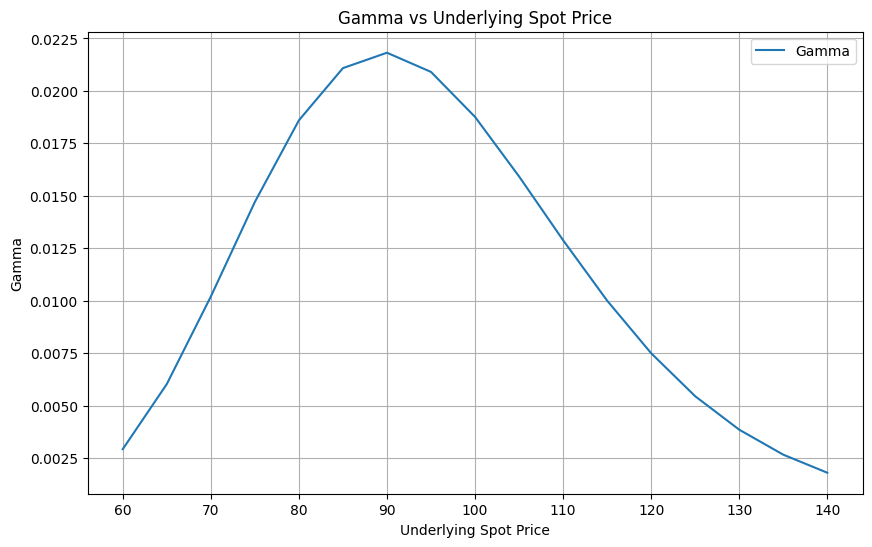

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(greeksSensitivityTable["Spot Price"], greeksSensitivityTable["Gamma"], label="Gamma")

plt.title("Gamma vs Underlying Spot Price")
plt.xlabel("Underlying Spot Price")
plt.ylabel("Gamma")
plt.legend()
plt.grid(True)
plt.show()

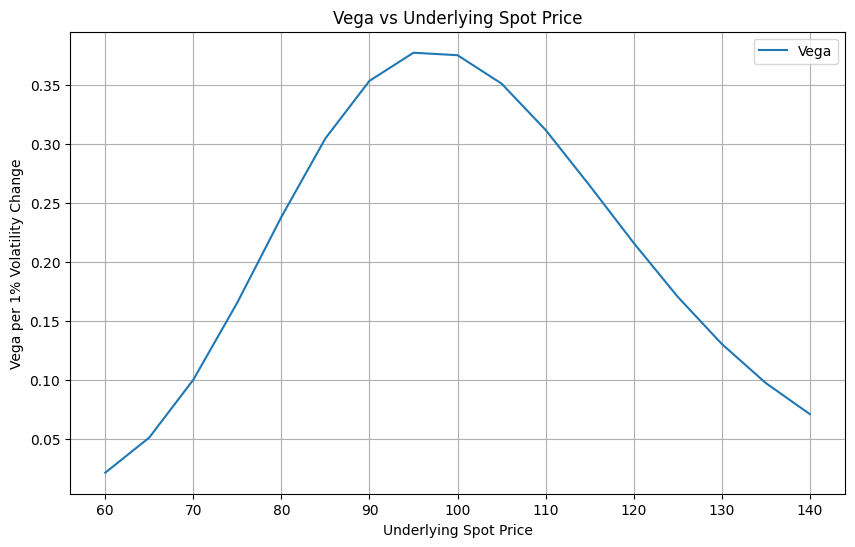

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(greeksSensitivityTable["Spot Price"], greeksSensitivityTable["Vega"], label="Vega")

plt.title("Vega vs Underlying Spot Price")
plt.xlabel("Underlying Spot Price")
plt.ylabel("Vega per 1% Volatility Change")
plt.legend()
plt.grid(True)
plt.show()

Gamma and Vega show a similar hump-shaped pattern because both depend on the standard normal density term φ(d1). They are usually highest when the option is close to at-the-money, but they measure different risks: Gamma measures the sensitivity of Delta to changes in the underlying price, while Vega measures the sensitivity of the option price to changes in volatility.

## 12. Option Payoff Diagrams

We now compare the payoff and profit profiles of long call and long put positions at maturity.

In [42]:
underlyingRange = np.arange(50, 155, 5)

callPayoff = np.maximum(underlyingRange - K, 0)
putPayoff = np.maximum(K - underlyingRange, 0)

callProfit = callPayoff - callPrice
putProfit = putPayoff - putPrice

payoffTable = pd.DataFrame({
    "Underlying Price at Maturity": underlyingRange,
    "Call Payoff": callPayoff,
    "Call Profit": callProfit,
    "Put Payoff": putPayoff,
    "Put Profit": putProfit
})

payoffTable

,Underlying Price at Maturity,Call Payoff,Call Profit,Put Payoff,Put Profit
0,50,0,-10.450584,50,44.426474
1,55,0,-10.450584,45,39.426474
2,60,0,-10.450584,40,34.426474
3,65,0,-10.450584,35,29.426474
4,70,0,-10.450584,30,24.426474
5,75,0,-10.450584,25,19.426474
6,80,0,-10.450584,20,14.426474
7,85,0,-10.450584,15,9.426474
8,90,0,-10.450584,10,4.426474
9,95,0,-10.450584,5,-0.573526


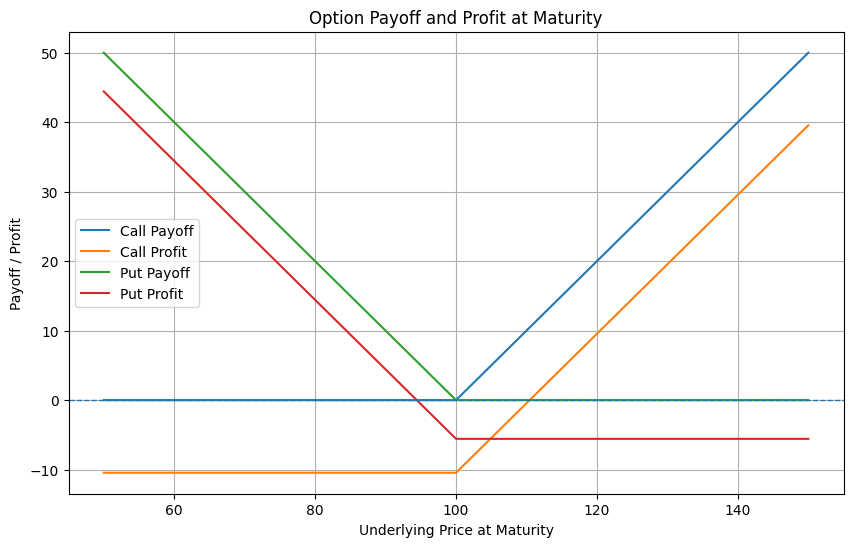

In [43]:
plt.figure(figsize=(10, 6))

plt.plot(underlyingRange, callPayoff, label="Call Payoff")
plt.plot(underlyingRange, callProfit, label="Call Profit")
plt.plot(underlyingRange, putPayoff, label="Put Payoff")
plt.plot(underlyingRange, putProfit, label="Put Profit")

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Option Payoff and Profit at Maturity")
plt.xlabel("Underlying Price at Maturity")
plt.ylabel("Payoff / Profit")
plt.legend()
plt.grid(True)
plt.show()

### Payoff vs Profit

The previous chart shows the payoff and profit profiles of simple long option positions: a long call and a long put.

A long call gives the holder the right to buy the underlying asset at the strike price. Its payoff at maturity is:

$$
\text{Call Payoff} = \max(S_T - K, 0)
$$

A long put gives the holder the right to sell the underlying asset at the strike price. Its payoff at maturity is:

$$
\text{Put Payoff} = \max(K - S_T, 0)
$$

It is important to distinguish between payoff and profit. The payoff is the value of the option at maturity before considering the premium paid. The profit subtracts the initial option premium:

$$
\text{Call Profit} = \text{Call Payoff} - \text{Call Premium}
$$

$$
\text{Put Profit} = \text{Put Payoff} - \text{Put Premium}
$$

Therefore, the buyer of a call or put has limited downside, equal to the premium paid, and potential upside if the underlying moves favourably.

This is not a butterfly strategy. A butterfly spread is a multi-leg options strategy that combines options with different strike prices. For example, a long call butterfly can be constructed by buying one lower-strike call, selling two middle-strike calls, and buying one higher-strike call. In contrast, this chart only shows the payoff and profit of individual long call and long put positions.

## 13. Key Takeaways

This project implements the Black-Scholes model in Python after first building the same logic in Excel.

The main results are:

- The theoretical call price increases when the underlying spot price increases.
- The theoretical put price decreases when the underlying spot price increases.
- Both call and put prices increase when volatility increases.
- Longer time to maturity generally increases the value of both calls and puts.
- Delta measures the sensitivity of the option price to the underlying spot price.
- Gamma measures how quickly Delta changes when the underlying moves.
- Vega measures the sensitivity of the option price to changes in volatility.
- Theta captures the effect of time decay.
- Rho measures the sensitivity to changes in interest rates.
- Put-call parity provides a useful no-arbitrage consistency check.
- Payoff and profit are different: profit subtracts the premium paid from the payoff.

Overall, the project shows how the Black-Scholes model can be used not only to calculate option prices, but also to understand option risk through Greeks and sensitivity analysis.